In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
import pandas as pd
import seaborn as sns
from collections import Counter

In [2]:
base_dir = '../../'
cell_table_path=base_dir+'segmentation/cell_table_Denoised/cell_table_size_normalized.csv'
biosamples_path=base_dir+'IMC_data/ExtraDocs/processed_response.csv'
intensities = pd.read_csv(cell_table_path)
if 'cell_meta_cluster' in intensities.columns:
    intensities = intensities[intensities['cell_meta_cluster']!='Unassigned']#remove cells that have not been assigned yet
biosamples =pd.read_csv(biosamples_path)
intensities_protein = intensities.iloc[:,1:intensities.columns.get_loc('label')]#proteins are from the second columns up to the column called label
adata = sc.AnnData(intensities_protein, obsm={"spatial": intensities[['centroid-0', 'centroid-1']].values})


/home/giuseppe/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [109]:

A = discretise(intensities_protein.values,0.3)
cond_few_genes_in_cell = np.sum(A,axis = 1)>0
Counter(cond_few_genes_in_cell)

Counter({True: 3964151, False: 45})

In [2]:
def discretise(data,thr):
    '''binarise the counts to 0/1'''
    if isinstance(data, sc.AnnData):
        return data.X>thr
    else:
        return data>thr
def normalise(adata,quantile=0.95):
    if isinstance(adata, sc.AnnData):
        data =  adata.copy().X
    else:
        data = adata.copy()
    if np.all(data<1):
        logger.warning('data seem already normalised, skipping normalisation')
        return adata
    q = np.quantile(data,q = quantile,axis = 0)
    data = data/q
    data[data>1] = 1
    if isinstance(adata, sc.AnnData):
        adata.X = data
        return adata
    else:
        return data
def quality_control(intensities,low_gene_active = 0.2,high_gene_active = 0.5):
    if 'pass_qc' in intensities.columns:
        return intensities['pass_qc']
    intensities_protein = intensities.iloc[:,1:intensities.columns.get_loc('label')]#proteins are from the second columns up to the column called label
    markers_4_phenotyping = ['CD38', 'CD14', 'Tbet', 'CD16', 'CD163',
       'Pan-keratin', 'CD11b', 'CD107a', 'CD45', 'CD44', 'CD366',
       'FOXP3', 'CD4', 'E-Cadherin', 'CD68', 'HLA-DR-DQ-DP', 'CD20',
       'CD8a', 'Beta-Catenin', 'B7-H4', 'Granzyme-B',
       'CD3', 'CD27', 'CD45RO',
       'Alpha-SMA', 'Vimentin', 'CD31' ]
    intensities_protein =    normalise(intensities_protein,0.95)
    A = intensities_protein.loc[:,markers_4_phenotyping]
    cond_few_genes_in_cell  = np.sum(discretise(A,thr = low_gene_active),axis=1)>0
    cond_many_genes_in_cell  = np.sum(discretise(A,thr = high_gene_active),axis=1)<11
    dna_count = intensities_protein[['DNA1', 'DNA2']].sum(axis = 1)
    dna_thr = np.quantile(dna_count,0.05)
    dna_cond = dna_count>dna_thr
    cond = cond_few_genes_in_cell& cond_many_genes_in_cell&dna_cond
    return cond


In [7]:
qc_pass = quality_control(intensities)


In [12]:
intensities['qc_pass'] = qc_pass

In [27]:
low_gene_active = 0.2
high_gene_active = 0.5
intensities_protein = intensities.iloc[:,1:intensities.columns.get_loc('label')]#proteins are from the second columns up to the column called label
markers_4_phenotyping = ['CD38', 'CD14', 'Tbet', 'CD16', 'CD163',
   'Pan-keratin', 'CD11b', 'CD107a', 'CD45', 'CD44', 'CD366',
   'FOXP3', 'CD4', 'E-Cadherin', 'CD68', 'HLA-DR-DQ-DP', 'CD20',
   'CD8a', 'Beta-Catenin', 'B7-H4', 'Granzyme-B',
   'CD3', 'CD27', 'CD45RO',
   'Alpha-SMA', 'Vimentin', 'CD31' ]
intensities_protein =    normalise(intensities_protein,0.95)
A = intensities_protein.loc[:,markers_4_phenotyping]
cond_few_genes_in_cell  = np.sum(discretise(A,thr = low_gene_active),axis=1)>0
cond_many_genes_in_cell  = np.sum(discretise(A,thr = high_gene_active),axis=1)<11

cond = cond_few_genes_in_cell& cond_many_genes_in_cell


/tmp/ipykernel_843522/3776987193.py:15: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  cond = cond_few_genes_in_cell* cond_many_genes_in_cell


In [41]:
dna_count = intensities_protein[['DNA1', 'DNA2']].sum(axis = 1)
dna_thr = np.quantile(dna_count,0.05)
cond_few_genes_in_cell& cond_many_genes_in_cell&(dna_count>dna_thr)

0          False
1          False
2           True
3          False
4           True
           ...  
3964191     True
3964192     True
3964193     True
3964194     True
3964195     True
Length: 3964196, dtype: bool

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


10.0

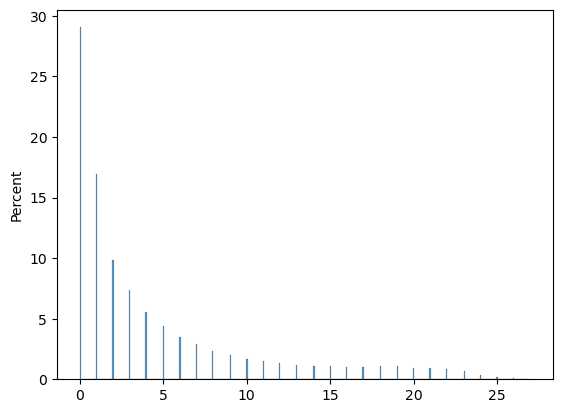

In [23]:
a = np.sum(discretise(A,thr = high_gene_active),axis=1)
sns.histplot(a,stat = 'percent',cumulative=False)
np.quantile(a,q = 0.85)

In [107]:
Counter(np.sum(discretise(a,0.3),axis=1))

Counter({27: 2237077,
         26: 590445,
         25: 262685,
         24: 160087,
         23: 108473,
         22: 78334,
         21: 62944,
         20: 55542,
         19: 51571,
         18: 48900,
         17: 45884,
         16: 41733,
         15: 37162,
         14: 34145,
         13: 31288,
         12: 27889,
         11: 23278,
         10: 19563,
         9: 15296,
         8: 11837,
         7: 8269,
         6: 5090,
         5: 3002,
         4: 1958,
         3: 1091,
         2: 536,
         1: 117})

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Percent'>

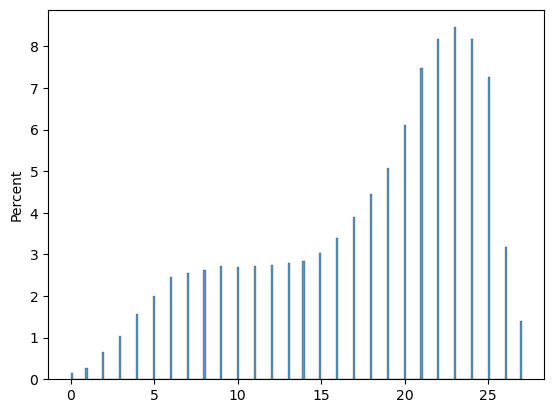

In [106]:
A = discretise(intensities_protein.loc[:,channels],0.5)
sns.histplot(np.sum(A,axis = 1),stat = 'percent')

Show those genes that yield the highest fraction of counts in each single cell, across all cells

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

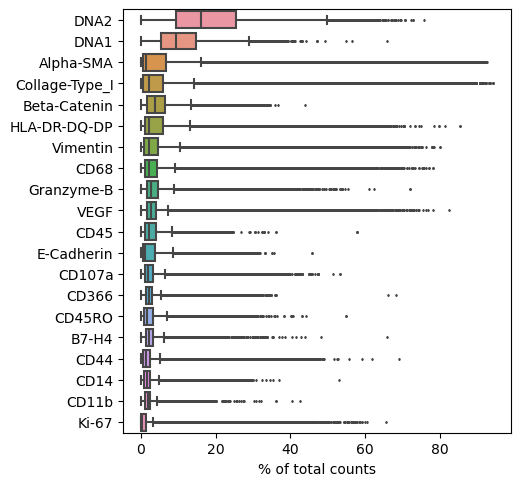

In [36]:
sc.pl.highest_expr_genes(adata, n_top=20, )


In [75]:
adata.raw = adata

In [24]:
#pd.DataFrame(np.quantile(adata.raw.X,0.95,axis = 0),adata.var.index)

normalise every channel independently to the 95 percentile

In [79]:
q = np.quantile(adata.X,q = 0.95,axis = 0)
adata.X = adata.X/q
adata.X[adata.X>1] = 1

If cells have low dna, it is likely that cells are rubbish, so we filter them out

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


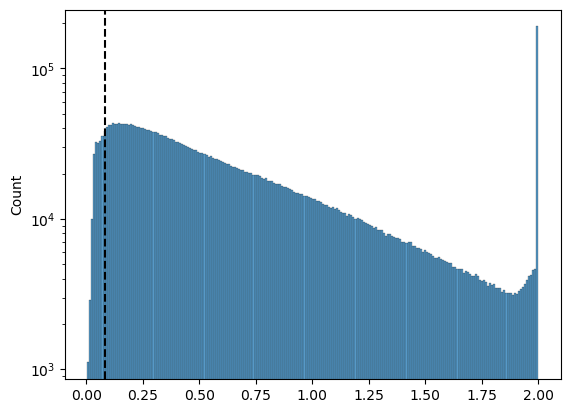

In [67]:
dna_count = adata[:,adata.var.index.isin(['DNA1', 'DNA2'])].X.sum(axis = 1)
sns.histplot(dna_count)
plt.semilogy()
dna_thr = np.quantile(dna_count,0.05)
plt.axvline(dna_thr,ls = '--',c = 'k')

In [68]:
adata=adata[dna_count>dna_thr]

For phenotyping , we  want the cells to express some markers, but not all together at the same time.
We are gonna use lower and higher bounds of total expression. Also remove DNA and Carboplatin as they do not have a role in phenotyping

In [ ]:
adata.raw

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


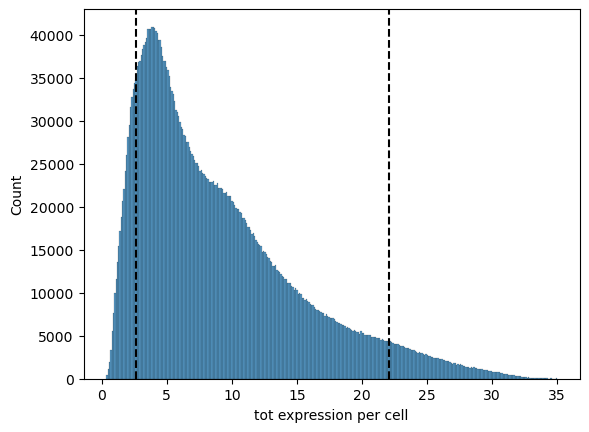

In [220]:
tot_counts = adata[:,~adata.var.index.isin(['DNA1', 'DNA2','Carboplatin'])].X.sum(axis = 1)
sns.histplot(tot_counts)
plt.xlabel('tot expression per cell')
plt.axvline(np.quantile(tot_counts,0.10),c = 'k',ls = '--')
plt.axvline(np.quantile(tot_counts,0.95),c = 'k',ls = '--')

In [ ]:
adata = adata[(tot_counts>np.quantile(tot_counts,0.10))*(tot_counts<np.quantile(tot_counts,0.95))]

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


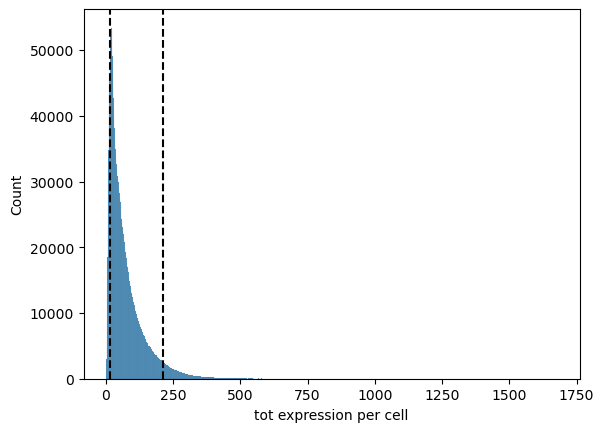

In [9]:
channels = ['CD38', 'CD14', 'Tbet', 'CD16', 'CD163',
       'Pan-keratin', 'CD11b', 'CD107a', 'CD45', 'CD44', 'CD366',
       'FOXP3', 'CD4', 'E-Cadherin', 'CD68', 'HLA-DR-DQ-DP', 'CD20',
       'CD8a', 'Beta-Catenin', 'B7-H4', 'Granzyme-B',
       'CD3', 'CD27', 'CD45RO',
       'Alpha-SMA', 'Vimentin', 'CD31' ]
tot_counts = adata[:,adata.var.index.isin(channels)].X.sum(axis = 1)
sns.histplot(tot_counts)
plt.xlabel('tot expression per cell')
plt.axvline(np.quantile(tot_counts,0.10),c = 'k',ls = '--')
plt.axvline(np.quantile(tot_counts,0.95),c = 'k',ls = '--')

In [ ]:
len(channels)

In [ ]:
adata=adata[adata.obs.total_counts>]


In [ ]:
adata.obs

In [ ]:
low_dna = adata[dna_count<0.1]
tot_counts = low_dna[:,~low_dna.var.index.isin(['DNA1', 'DNA2','Carboplatin'])].X.sum(axis = 1)
sns.histplot(tot_counts)
plt.xlabel('tot expression per cell')
plt.axvline(np.quantile(tot_counts,0.10),c = 'k',ls = '--')
plt.axvline(np.quantile(tot_counts,0.95),c = 'k',ls = '--')

In [ ]:
plt.hist(adata.X.reshape(-1),cumulative=True)

In [ ]:
plt.hist(adata.X.reshape(-1),bins = 30)

In [11]:
def discretise(adata,thr):
    '''binarise the counts to 0/1'''
    return adata.X>thr


In [76]:
adata.raw

In [80]:
dna_count = adata[:,adata.var.index.isin(['DNA1', 'DNA2'])].X.sum(axis = 1)
tot_counts = adata[:,adata.var.index.isin(channels)].X.sum(axis = 1)
tot_genes = discretise(adata[:,adata.var.index.isin(channels)],thr = 0.5).sum(axis = 1)

In [70]:
adata#[tot_genes>1]

View of AnnData object with n_obs × n_vars = 3765986 × 38
    obsm: 'spatial'

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


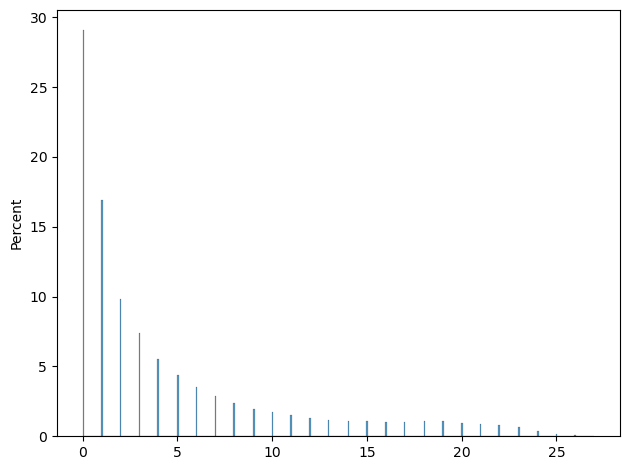

In [81]:
sns.histplot(tot_genes,stat = 'percent')
plt.tight_layout()
#plt.savefig('figures/tot_genes_0.3.png')

In [ ]:
tot

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


array([ 8., 10., 14.])

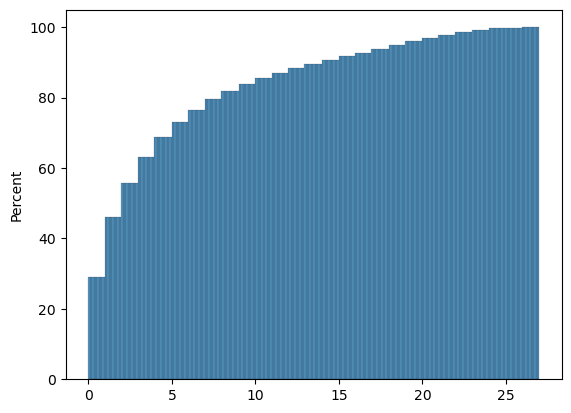

In [66]:
sns.histplot(tot_genes,stat = 'percent',cumulative=True)
np.quantile(tot_genes,q=[0.8,0.85,0.9])

In [67]:
from collections import Counter
k,v = zip(*Counter(tot_genes).items())
v = np.array(v)[np.argsort(k)]
k = np.sort(k)
dict(zip(k,(np.cumsum(v)/np.sum(v))))


{0: 0.2906316942956403,
 1: 0.45986323582385935,
 2: 0.5582799135057903,
 3: 0.6322994624887367,
 4: 0.687604750118309,
 5: 0.7311883670736765,
 6: 0.7662597913927566,
 7: 0.795421063943357,
 8: 0.819157024526537,
 9: 0.8390230957298781,
 10: 0.8560969235628108,
 11: 0.8710419464627884,
 12: 0.8842610203935426,
 13: 0.8960321336281052,
 14: 0.907052527170705,
 15: 0.9176672899120023,
 16: 0.9281655094753135,
 17: 0.9387030812805421,
 18: 0.9492981679008807,
 19: 0.9598932545212194,
 20: 0.9695471666890335,
 21: 0.978650651985926,
 22: 0.9869229473012939,
 23: 0.9936140897170573,
 24: 0.9975109706987243,
 25: 0.999131980356168,
 26: 0.9998208968476836,
 27: 1.0}

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to 

<Axes: ylabel='Count'>

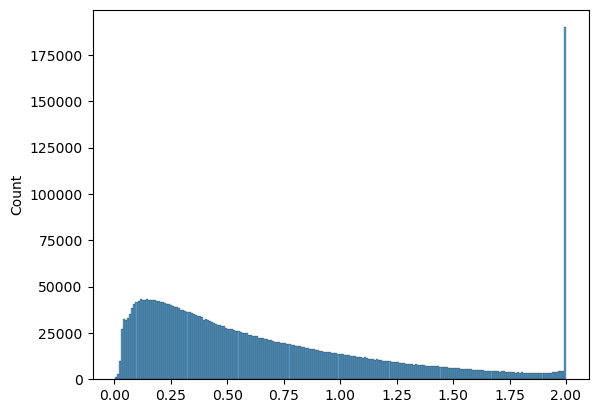

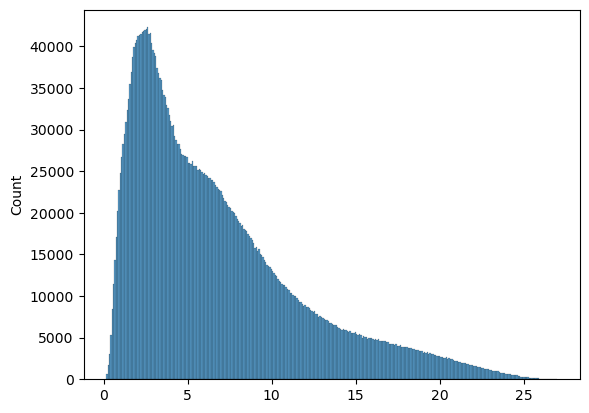

In [12]:
sns.histplot(dna_count)
plt.figure()
sns.histplot(tot_counts).

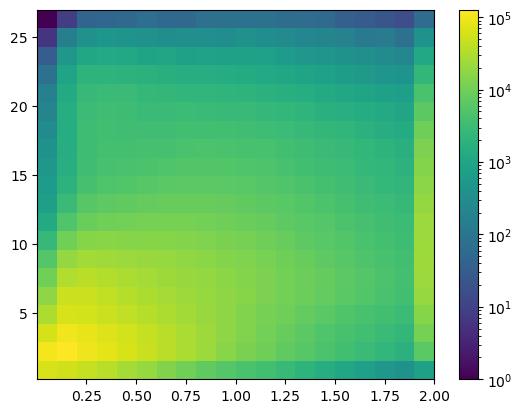

In [41]:
_ = plt.hist2d(dna_count,tot_counts,bins = 20, norm=LogNorm())
plt.colorbar()


<Figure size 640x480 with 0 Axes>

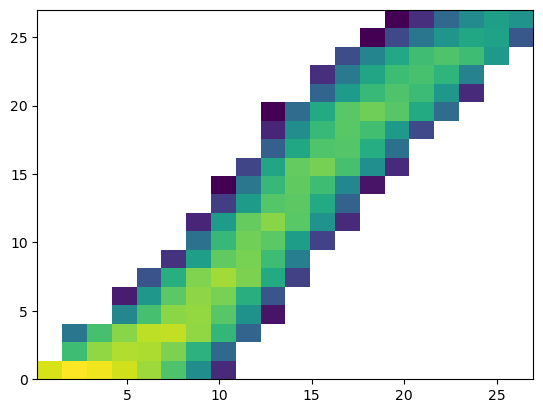

<Figure size 640x480 with 0 Axes>

In [42]:
_ = plt.hist2d(tot_counts, tot_genes,bins = 20, norm=LogNorm())
plt.figure()


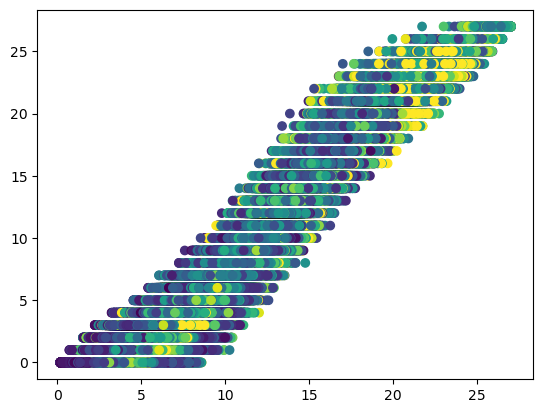

In [20]:
plt.scatter(tot_counts, tot_genes,c = dna_count)

In [61]:
tot_counts = discretise(adata[:,adata.var.index.isin(channels)],thr = 0.3).sum(axis = 1)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Percent'>

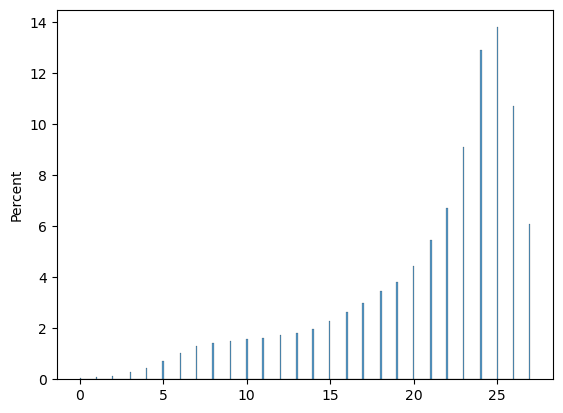

In [62]:
sns.histplot(tot_counts,stat='percent')

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


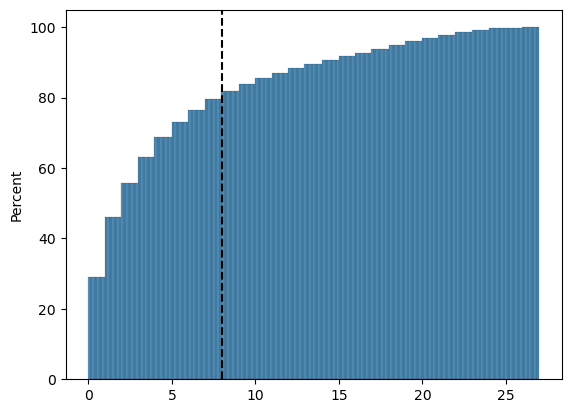

In [201]:
sns.histplot(tot_counts,stat='percent',cumulative=True)
plt.axvline(np.quantile(tot_counts,.80),ls = '--',c ='k')
#plt.axhline(10,ls = '--',c ='k')

In [193]:
np.quantile(tot_counts,0.8)

15.0

In [ ]:
from collections import Counter

In [ ]:
b,c = list(zip(*Counter(tot_counts).items()))

In [ ]:
Counter(a)

In [ ]:
plt.bar(b,np.array(c)/sum(c),0.5)

In [ ]:
plt.bar(np.arange(len(b)),np.cumsum(c)/sum(c),0.5)

(array([  5311.,  49495.,  71402.,  79832.,  91070.,  94535.,  94866.,
         94732.,  94397.,  93466.,  92016.,  90034.,  88310.,  85861.,
         83859.,  81952.,  79513.,  77590.,  75423.,  72346.,  71092.,
         68547.,  66036.,  64197.,  62016.,  60256.,  58649.,  57090.,
         55042.,  53875.,  52017.,  50754.,  49197.,  47998.,  46585.,
         44909.,  44336.,  43141.,  42023.,  40424.,  39438.,  38669.,
         37546.,  36375.,  35133.,  34242.,  32877.,  32283.,  31234.,
         30586.,  29557.,  28781.,  27596.,  26824.,  26320.,  25784.,
         24511.,  23581.,  23359.,  22480.,  21802.,  20912.,  20131.,
         19701.,  18726.,  18429.,  17378.,  17326.,  16466.,  15994.,
         15351.,  15400.,  14441.,  14099.,  13559.,  13301.,  12730.,
         12209.,  11929.,  11653.,  11235.,  10629.,  10238.,   9935.,
          9722.,   9229.,   9325.,   8728.,   8248.,   8224.,   7841.,
          7637.,   7321.,   7119.,   7067.,   7167.,   7907.,   8526.,
      

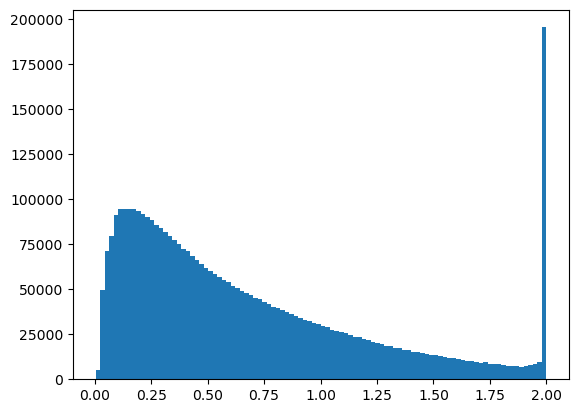

In [213]:
plt.hist(adata[:,adata.var.index.isin(['DNA1','DNA2'])].X.sum(axis = 1),bins = 100)

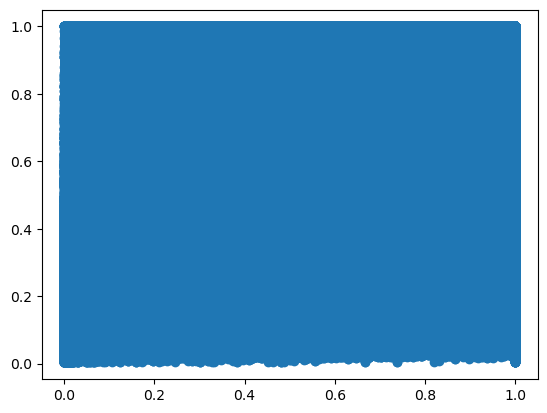

In [75]:
plt.hist2d(adata[:,adata.var.index=='Ki-67'].X.reshape(-1),adata[:,adata.var.index=='DNA1'].X.reshape(-1),norm = )

In [15]:
adata

AnnData object with n_obs × n_vars = 3964196 × 38
    obsm: 'spatial'

In [16]:
cell_table = pd.read_csv(cell_table_path)